In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import io
import zipfile
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


def download_file(url: str, dest: Path, timeout: int = 45):
    if dest.exists():
        return dest
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    dest.write_bytes(r.content)
    return dest


def print_source(name: str, mode: str):
    print(f"[{name}] data source: {mode}")

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification


def load_heart_data():
    local_csv = DATA_DIR / "heart.csv"
    if local_csv.exists():
        df = pd.read_csv(local_csv)
        print_source("Heart", "local csv")
        return df

    try:
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
        cols = [
            "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
            "exang", "oldpeak", "slope", "ca", "thal", "num"
        ]
        df = pd.read_csv(url, header=None, names=cols, na_values="?")
        print_source("Heart", "downloaded UCI Cleveland")
        return df
    except Exception as e:
        print("Download failed, using synthetic fallback:", e)

    X, y = make_classification(
        n_samples=3000,
        n_features=13,
        n_informative=8,
        n_redundant=2,
        weights=[0.55, 0.45],
        random_state=42,
    )
    df = pd.DataFrame(X, columns=[f"f{i}" for i in range(13)])
    df["target"] = y
    print_source("Heart", "synthetic fallback")
    return df


df = load_heart_data()
print("Shape:", df.shape)
df.head()

[Heart] data source: downloaded UCI Cleveland
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
target_col = next((c for c in ["target", "num", "HeartDisease", "output"] if c in df.columns), None)
if target_col is None:
    raise ValueError(f"Could not identify target column from: {list(df.columns)}")

X = df.drop(columns=[target_col]).copy()
y = (pd.to_numeric(df[target_col], errors="coerce").fillna(0) > 0).astype(int)

for c in X.columns:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42)),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

           0     0.9310    0.8182    0.8710        33
           1     0.8125    0.9286    0.8667        28

    accuracy                         0.8689        61
   macro avg     0.8718    0.8734    0.8688        61
weighted avg     0.8766    0.8689    0.8690        61

ROC-AUC: 0.9502


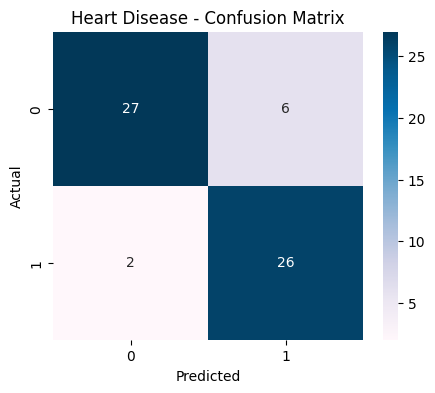

In [4]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuBu")
plt.title("Heart Disease - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()